In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle
from matplotlib.colors import LogNorm  # Import LogNorm for logarithmic color scale

DataTitle="Data_dynamics"

np.random.seed(1)
if not os.path.exists(DataTitle):

   # Create a new directory because it does not exist
   os.makedirs(DataTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

sns.color_palette("tab10")

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

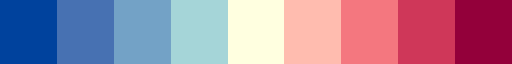

In [3]:
my_cmap

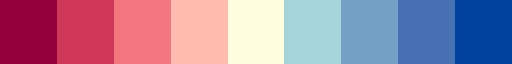

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




In [6]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

########################################################
########################################################
# Fig 3-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [7]:
def uniform_distribution(u,o):
    return (2*u+2*o)*np.random.random()-o

def uniform_distribution(u,o):
    return (2*u+2*o)*np.random.random()-o

def input_distribution():
    k=0.8
    return np.random.exponential(k)

def InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path="Data/test"):
    
    CommunitiesLibrary=np.zeros([num_C, N])
    for i in range(num_C):
        #CommunitiesLibrary[i,random.sample(list(np.arange(N)), num_S)]=1
        CommunitiesLibrary[i,np.arange(num_S*i,num_S*(i+1))]=1
    df1=pd.DataFrame(CommunitiesLibrary)
    with pd.ExcelWriter(save_path+'/commuityLibrary.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
    return CommunitiesLibrary


In [8]:
session_name="Data/MostAbundant_U_dependency_Normalized_S24"
if not os.path.exists(session_name):

   # Create a new directory because it does not exist
   os.makedirs(session_name)
   print("The new directory is created!")


###################
######################################
#########################################################

N_simul=200
S=24
u_list=np.arange(0,1.0,0.1)
o=0
t=[0,5000]
num_C=2
num_S=24
N=num_C*num_S
threshold=1e-3

###################
######################################
#########################################################
Intention_to_reset=False
if Intention_to_reset or not os.path.isfile(session_name+'/Data_Assymetricity.xlsx'):
    Data_Assymetricity=np.zeros((len(u_list),N_simul))
    Data_Similarity_to_1=np.zeros((len(u_list),N_simul))
    Data_MostAbundant_y1=np.zeros((len(u_list),N_simul))
    Data_MostAbundant_y2=np.zeros((len(u_list),N_simul))
    Data_MostAbundant_I12=np.zeros((len(u_list),N_simul))
    Data_MostAbundant_I21=np.zeros((len(u_list),N_simul))

    for i,u in enumerate(u_list):
        for itt in range(N_simul):
            ###########
            np.random.seed(itt)
            f_interaction=lambda : uniform_distribution(u,o)

            I,g,k= InitializeSpeceiesPool(N, f_interaction, f_g = lambda :np.ones(1),f_k = lambda :np.ones(1), is_diagonal_one=True, save_path=session_name)

            CommunitiesLibrary= InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name)

            y=np.random.rand(N)*0.1
            y1=run_lotka_volterra(y, t, CommunitiesLibrary[0,:], I, g, k)
            y2=run_lotka_volterra(y, t, CommunitiesLibrary[1,:], I, g, k)

            y1[y1<threshold]=0
            y2[y2<threshold]=0
            y3=np.array((y1/sum(y1)+y2/sum(y2))/2)
            survived=y3>threshold
            y3=run_lotka_volterra(y3, t, survived, I, g, k)
            y3[y3<threshold]=0
            Similarity_to1 =(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityBC(x,y,z)))

            i1=argmax(y1)
            i2=argmax(y2)
            
            Assimilarity_BC=abs(2* Similarity_to1-1)
            Data_Assymetricity[i,itt]=Assimilarity_BC
            Data_Similarity_to_1[i,itt]=Similarity_to1
            Data_MostAbundant_y1[i,itt]=max(y1)/sum(y1)
            Data_MostAbundant_y2[i,itt]=max(y2)/sum(y2)
            Data_MostAbundant_I12[i,itt]=I[i1,i2]
            Data_MostAbundant_I21[i,itt]=I[i2,i1]
            

            #print(max(y1)/sum(y1),max(y2)/sum(y2), I[i1,i2],I[i2,i1], Similarity_to1)
            #########

    df1=pd.DataFrame(Data_Assymetricity) 
    df2=pd.DataFrame(Data_Similarity_to_1)
    df3=pd.DataFrame(Data_MostAbundant_y1)
    df4=pd.DataFrame(Data_MostAbundant_y2)
    df5=pd.DataFrame(Data_MostAbundant_I12)
    df6=pd.DataFrame(Data_MostAbundant_I21)
    with pd.ExcelWriter(session_name+'/Data_Assymetricity.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
        df2.to_excel(writer,sheet_name='Sheet2')
        df3.to_excel(writer,sheet_name='Sheet3')
        df4.to_excel(writer,sheet_name='Sheet4')
        df5.to_excel(writer,sheet_name='Sheet5')
        df6.to_excel(writer,sheet_name='Sheet6')

        

In [9]:
df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet1')
df = df.values[0:,1:]
df1 = df

df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet2')
df = df.values[0:,1:]
df2 = df

df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet3')
df = df.values[0:,1:]
df3 = df

df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet4')
df = df.values[0:,1:]
df4 = df

df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet5')
df = df.values[0:,1:]
df5 = df

df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet6')
df = df.values[0:,1:]
df6 = df


In [10]:
a=0.0533
b=1.2
print(pairwiseResultFromCoefficient(b,a))

NameError: name 'pairwiseResultFromCoefficient' is not defined

In [11]:

def pairwiseResultFromCoefficient(a,b):
    if a<1 and  b<1:
        x=(1-b)/(1-b*a)
        r=(1-x)/b/x
        return 0, (1)/(1+r)

    if a>1 and b<1:
        return 1, 1

    if a<1 and  b>1:
        return 2, 0

    if a>1 and  b>1:
        return 3, a>b
    

In [12]:
i=8
x=[]
y=[]
for j in range(df1.shape[1]):
    if True:
    #if pairwiseResultFromCoefficient(df6[i,j],df5[i,j])[0] !=3:
        x.append(pairwiseResultFromCoefficient(df6[i,j],df5[i,j])[1])
        y.append(df2[i,j])
        x.append(1-pairwiseResultFromCoefficient(df6[i,j],df5[i,j])[1])
        y.append(1-df2[i,j])
x=np.array(x)
y=np.array(y)

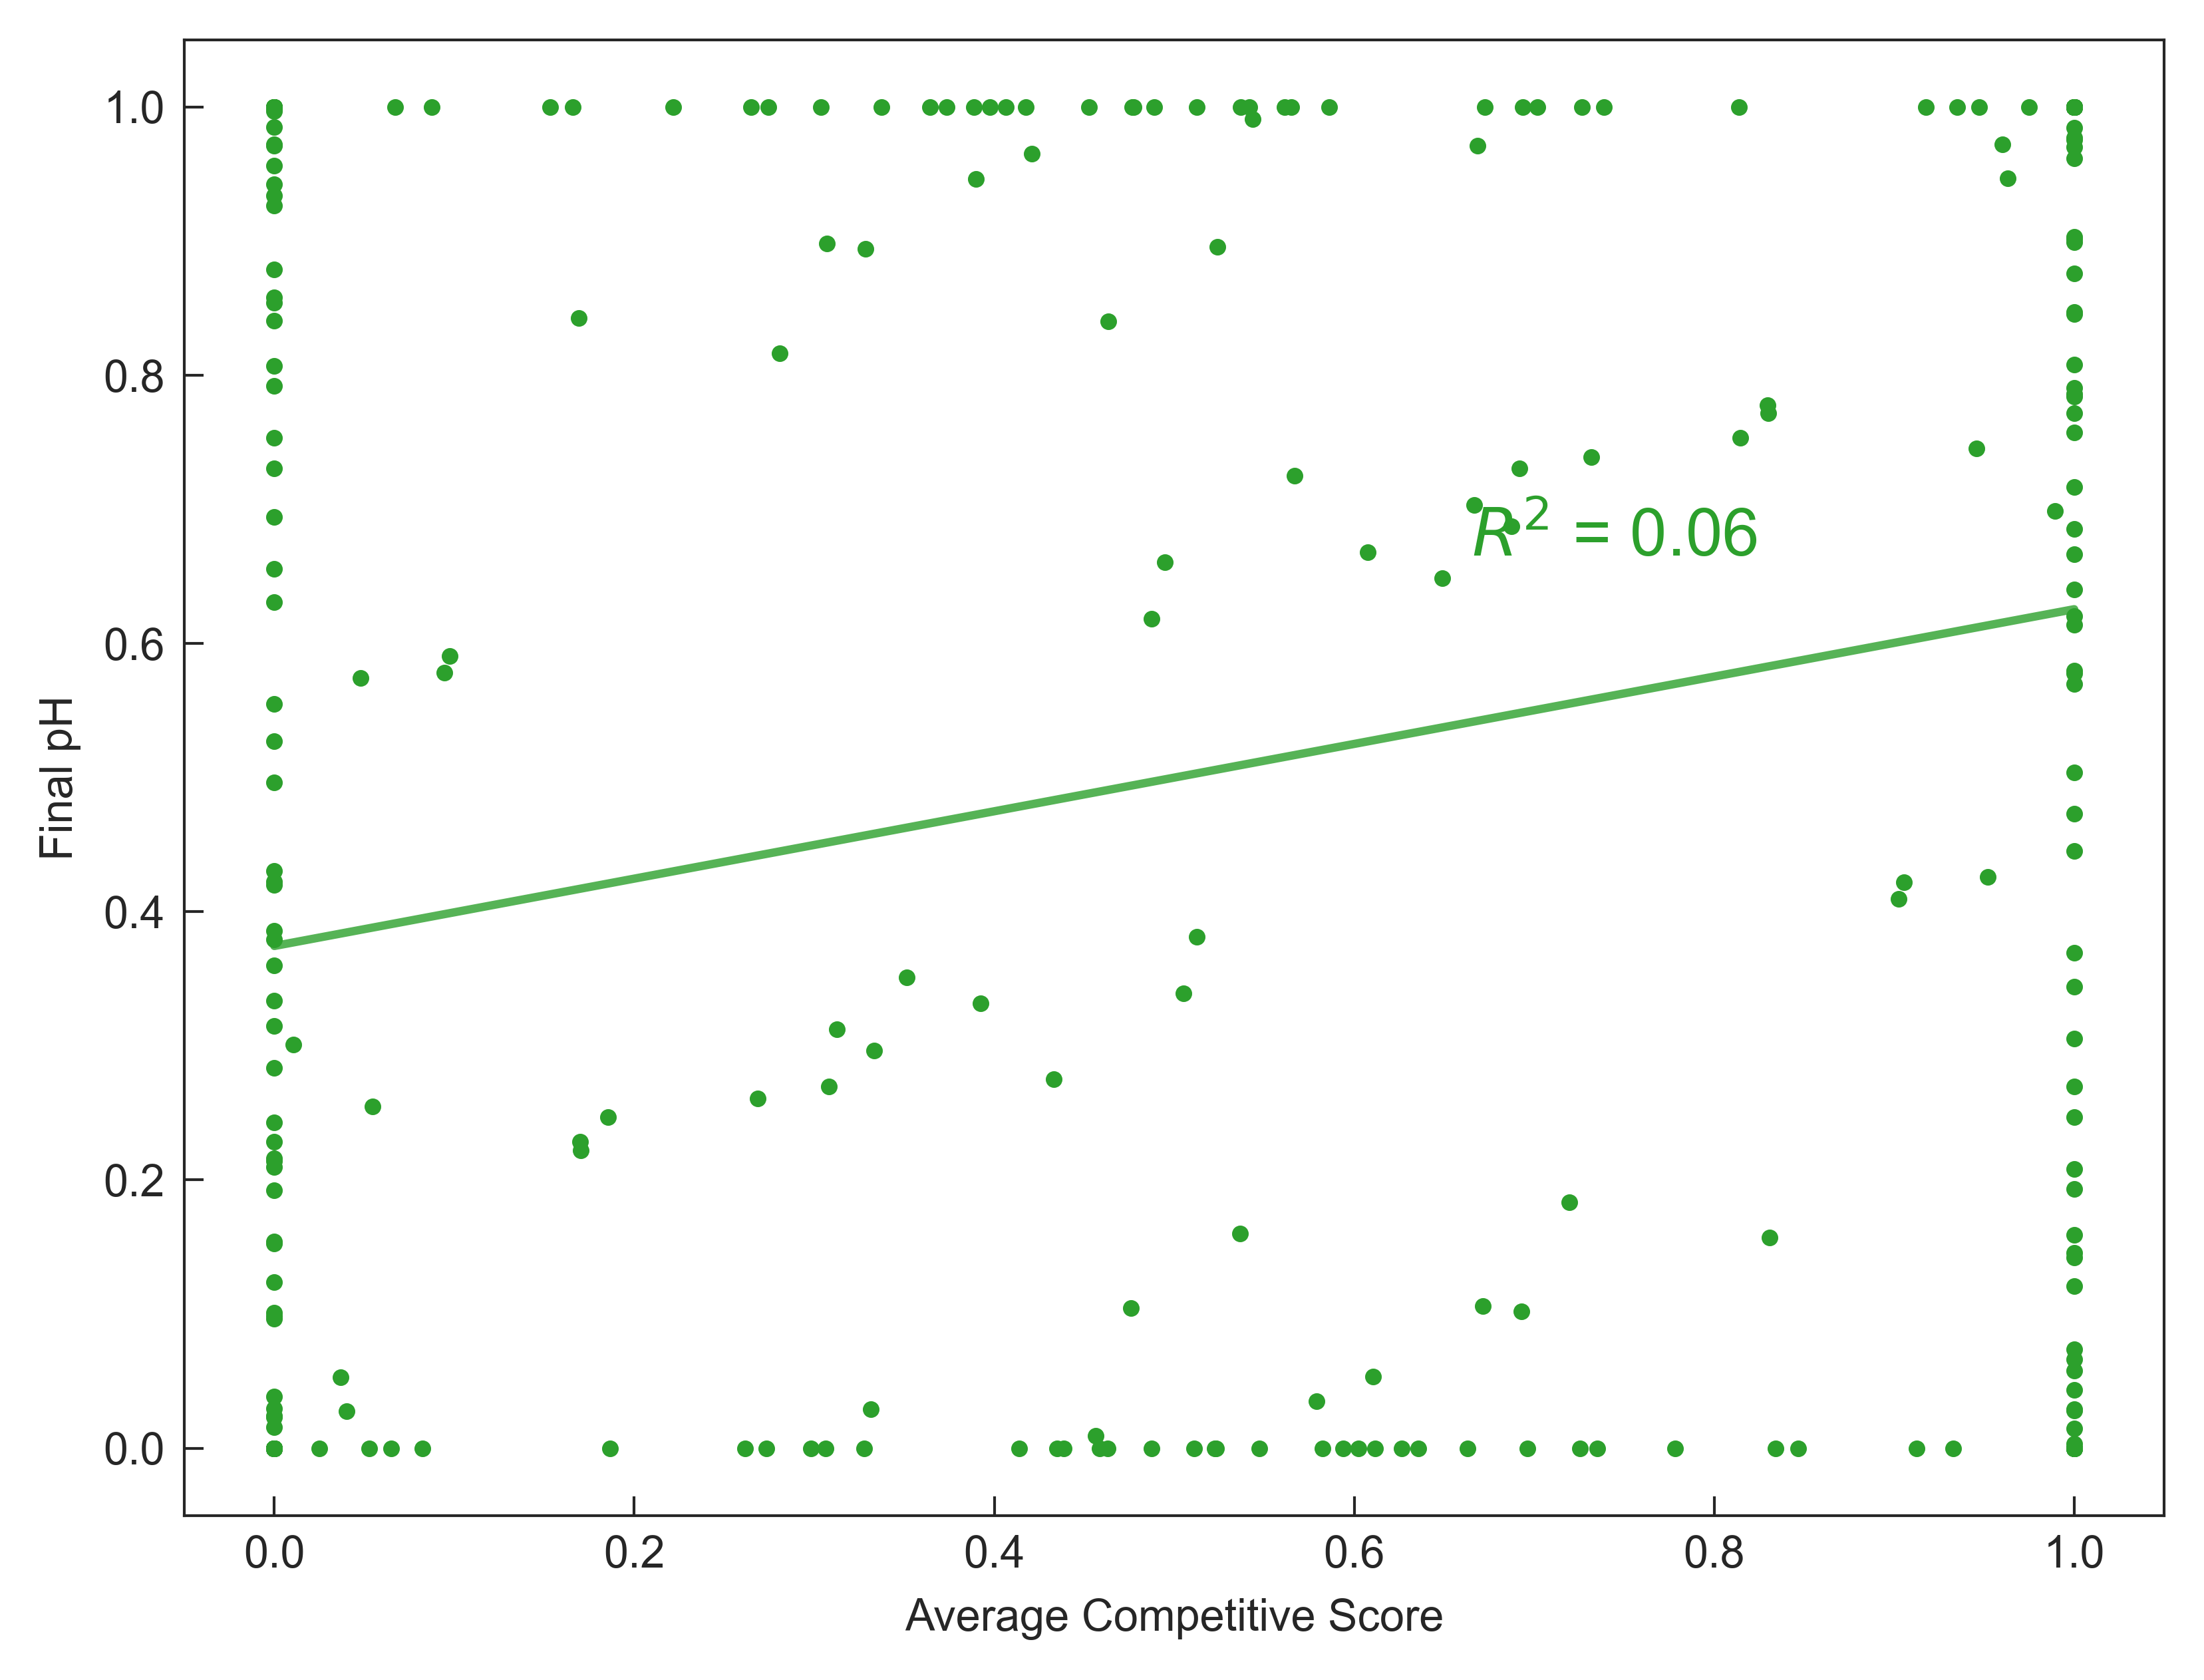

In [13]:
colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

if True:
    i=0
    plt.scatter(x,y,s=0.5)
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
        # Create a scatter plot of the data
    plt.scatter(x, y, color=colors[i], s=4)
    # Add the linear regression line to the plot
    plt.plot([0,1], slope * np.array([0,1]) + intercept, color=colors[i], alpha=0.8)
                # Add the R-squared value to the plot
    plt.annotate('$R^2$ = {:.2f}'.format(r_squared), xy=(0.05+0.6, 0.65), xycoords='axes fraction', fontsize=12, color=colors[i])

    plt.xlabel('Average Competitive Score')
    plt.ylabel('Final pH')
    plt.xlim(-0.05,1.05)

In [40]:
np.mean(df3[8,:])

0.5190665988887323

In [41]:
sum((x<0.25)*(y<0.25))/len(x),  sum((x>0.25)*(x<0.5)*(y<0.25))/len(x) , sum((x>0.5)*(x<0.75)*(y<0.25))/len(x) ,  sum((x>0.75)*(y<0.25))/len(x)

(0.22, 0.035, 0.05, 0.12)

In [42]:
print(sum((x<0.33)*(y>0.33)*(y<0.66))/len(x),  sum((x>0.33)*(x<0.66)*(y>0.33)*(y<0.66))/len(x) , sum((x>0.66)*(y>0.33)*(y<0.66))/len(x))
print(sum((x<0.33)*(y<0.33))/len(x),  sum((x>0.33)*(x<0.66)*(y<0.33))/len(x) , sum((x>0.66)*(y<0.33))/len(x))

0.0375 0.015 0.035
0.25 0.06 0.1425


In [14]:
Pairwise_Count_data_path="../../Postprocessed/PairwiseColonyCountings_processed_230915.xlsx"

def getPairwiseCountData():
    Mono_Count_data={}
    Pairwise_Count_data={}
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=0)
    Data=np.transpose(np.array(Data.values[:,1:]))
    Mono_Count_data["LN"]=Data
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=1)
    Data=np.transpose(np.array(Data.values[:,1:]))
    Mono_Count_data["MN"]=Data
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=2)
    Data=np.transpose(np.array(Data.values[:,1:]))
    Mono_Count_data["HN"]=Data
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=3)
    Data=np.array(Data.values[:,1:])
    Data_1=Data #This is the species for the first index
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=4)
    Data=np.array(Data.values[:,1:])
    Data_2=Data #This is the species for the second index
    Data=np.stack([Data_1,Data_2])
    Pairwise_Count_data["LN"]=Data

    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=5)
    Data=np.array(Data.values[:,1:])
    Data_1=Data #This is the species for the first index
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=6)
    Data=np.array(Data.values[:,1:])
    Data_2=Data #This is the species for the second index
    Data=np.stack([Data_1,Data_2])
    Pairwise_Count_data["MN"]=Data

    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=7)
    Data=np.array(Data.values[:,1:])
    Data_1=Data #This is the species for the first index
    Data=pd.read_excel(Pairwise_Count_data_path, sheet_name=8)
    Data=np.array(Data.values[:,1:])
    Data_2=Data #This is the species for the second index
    Data=np.stack([Data_1,Data_2])
    Pairwise_Count_data["HN"]=Data
    return Mono_Count_data, Pairwise_Count_data

def getProcessedPairwiseCountData(Mono_Count_data, Pairwise_Count_data, medium_type):
    data_m=np.mean(Mono_Count_data[medium_type],1)
    data_p_1=Pairwise_Count_data[medium_type][0,:]
    data_p_2=Pairwise_Count_data[medium_type][1,:]
    data_flag=np.array([[None] * 12]*12)
    data_p_1_converted=np.array([[None] * 12]*12)
    data_p_2_converted=np.array([[None] * 12]*12)
    data_p_ratio=np.array([[None] * 12]*12)

    count=0
    for i in range(12):
        for j in range(12):
            if np.isnan(data_p_1[i,j]):
                data_flag[i,j]='case0' # No data
            else:
                if data_p_1[i,j]==1 and data_p_2[i,j]==0 :
                    #print(i,j,'case1') # species i dominates
                    data_flag[i,j]='case1'
                    data_p_1_converted[i,j]=1
                    data_p_2_converted[i,j]=0
                    data_p_ratio[i,j]=1

                elif data_p_1[i,j]==0 and data_p_2[i,j]==1 :
                    #print(i,j,'case2') # species j dominates
                    data_flag[i,j]='case2'
                    data_p_1_converted[i,j]=0
                    data_p_2_converted[i,j]=1
                    data_p_ratio[i,j]=0

                else:
                    #print(i,j,'case3') # species i, j coexists
                    data_flag[i,j]='case3'
                    data_p_1_converted[i,j]=data_p_1[i,j]/data_m[i]
                    data_p_2_converted[i,j]=data_p_2[i,j]/data_m[j]
                    data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])
    return data_p_1,data_p_2,data_flag,data_p_ratio


Pairwise_Count_data_path="../../Postprocessed/PairwiseColonyCountings_processed_230915.xlsx"

def getProcessedPairwiseSimulation(Mono_Count_data, Pairwise_Count_data, medium_type):
    data_m=np.mean(Mono_Count_data[medium_type],1)
    data_p_1=Pairwise_Count_data[medium_type][0,:]
    data_p_2=Pairwise_Count_data[medium_type][1,:]
    data_flag=np.array([[None] * 12]*12)
    data_p_1_converted=np.array([[None] * 12]*12)
    data_p_2_converted=np.array([[None] * 12]*12)
    data_p_ratio=np.array([[None] * 12]*12)

    count=0
    for i in range(12):
        for j in range(12):
            if np.isnan(data_p_1[i,j]):
                data_flag[i,j]='case0' # No data
            else:
                if data_p_1[i,j]==1 and data_p_2[i,j]==0 :
                    #print(i,j,'case1') # species i dominates
                    data_flag[i,j]='case1'
                    data_p_1_converted[i,j]=1
                    data_p_2_converted[i,j]=0
                    data_p_ratio[i,j]=1

                elif data_p_1[i,j]==0 and data_p_2[i,j]==1 :
                    #print(i,j,'case2') # species j dominates
                    data_flag[i,j]='case2'
                    data_p_1_converted[i,j]=0
                    data_p_2_converted[i,j]=1
                    data_p_ratio[i,j]=0

                else:
                    #print(i,j,'case3') # species i, j coexists
                    data_flag[i,j]='case3'
                    data_p_1_converted[i,j]=data_p_1[i,j]/data_m[i]
                    data_p_2_converted[i,j]=data_p_2[i,j]/data_m[j]
                    data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])
    return data_p_1,data_p_2,data_flag,data_p_ratio


Mono_Count_data,Pairwise_Count_data=getPairwiseCountData()

In [18]:
data_p_ratio

array([[None, 0.22462835069647663, 0, 0.3354745819027578, 1, 1, 1,
        0.6346604215456674, 0.5645536010620644, 0.5733333333333334, 0, 1],
       [0, None, 0, 0.8353976531942633, 1, None, 1, 1, 0,
        0.39520958083832336, 1, 0.0790273556231003],
       [1, 0.8623265741728923, None, 1, 1, 1, 1, 1, 0, 1, None, 1],
       [0, 0.06451318550962679, 0, None, 0.601027397260274,
        0.4618937644341802, 0.6553646603709182, 1, 0, 0.3376918703808982,
        0, 0.04582683307332293],
       [0, 0, 0, 0.45039041635933563, None, 0.29202660347068266, 0, None,
        0.7003891050583658, 0.07352941176470588, 0, 0.16159695817490494],
       [0, None, 0, 0.5434855048317228, 0, None, None, 0,
        0.9310344827586207, 0.8407643312101911, 0, 0.7064220183486238],
       [0, 0, 0, 0.3303671832982937, 1, None, None, 1,
        0.4003231017770598, 0.3447098976109215, 0, 0.08595609627082783],
       [0, 0, 0, 0, None, 1, 0, None, 0.24637177370296343, 0, 0,
        0.07337227525288502],
       [0, 

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_21784/3678156086.py:77: RuntimeWarning: invalid value encountered in scalar divide
  data_p_ratio[i,j]=data_p_1_converted[i,j]/(data_p_1_converted[i,j]+data_p_2_converted[i,j])


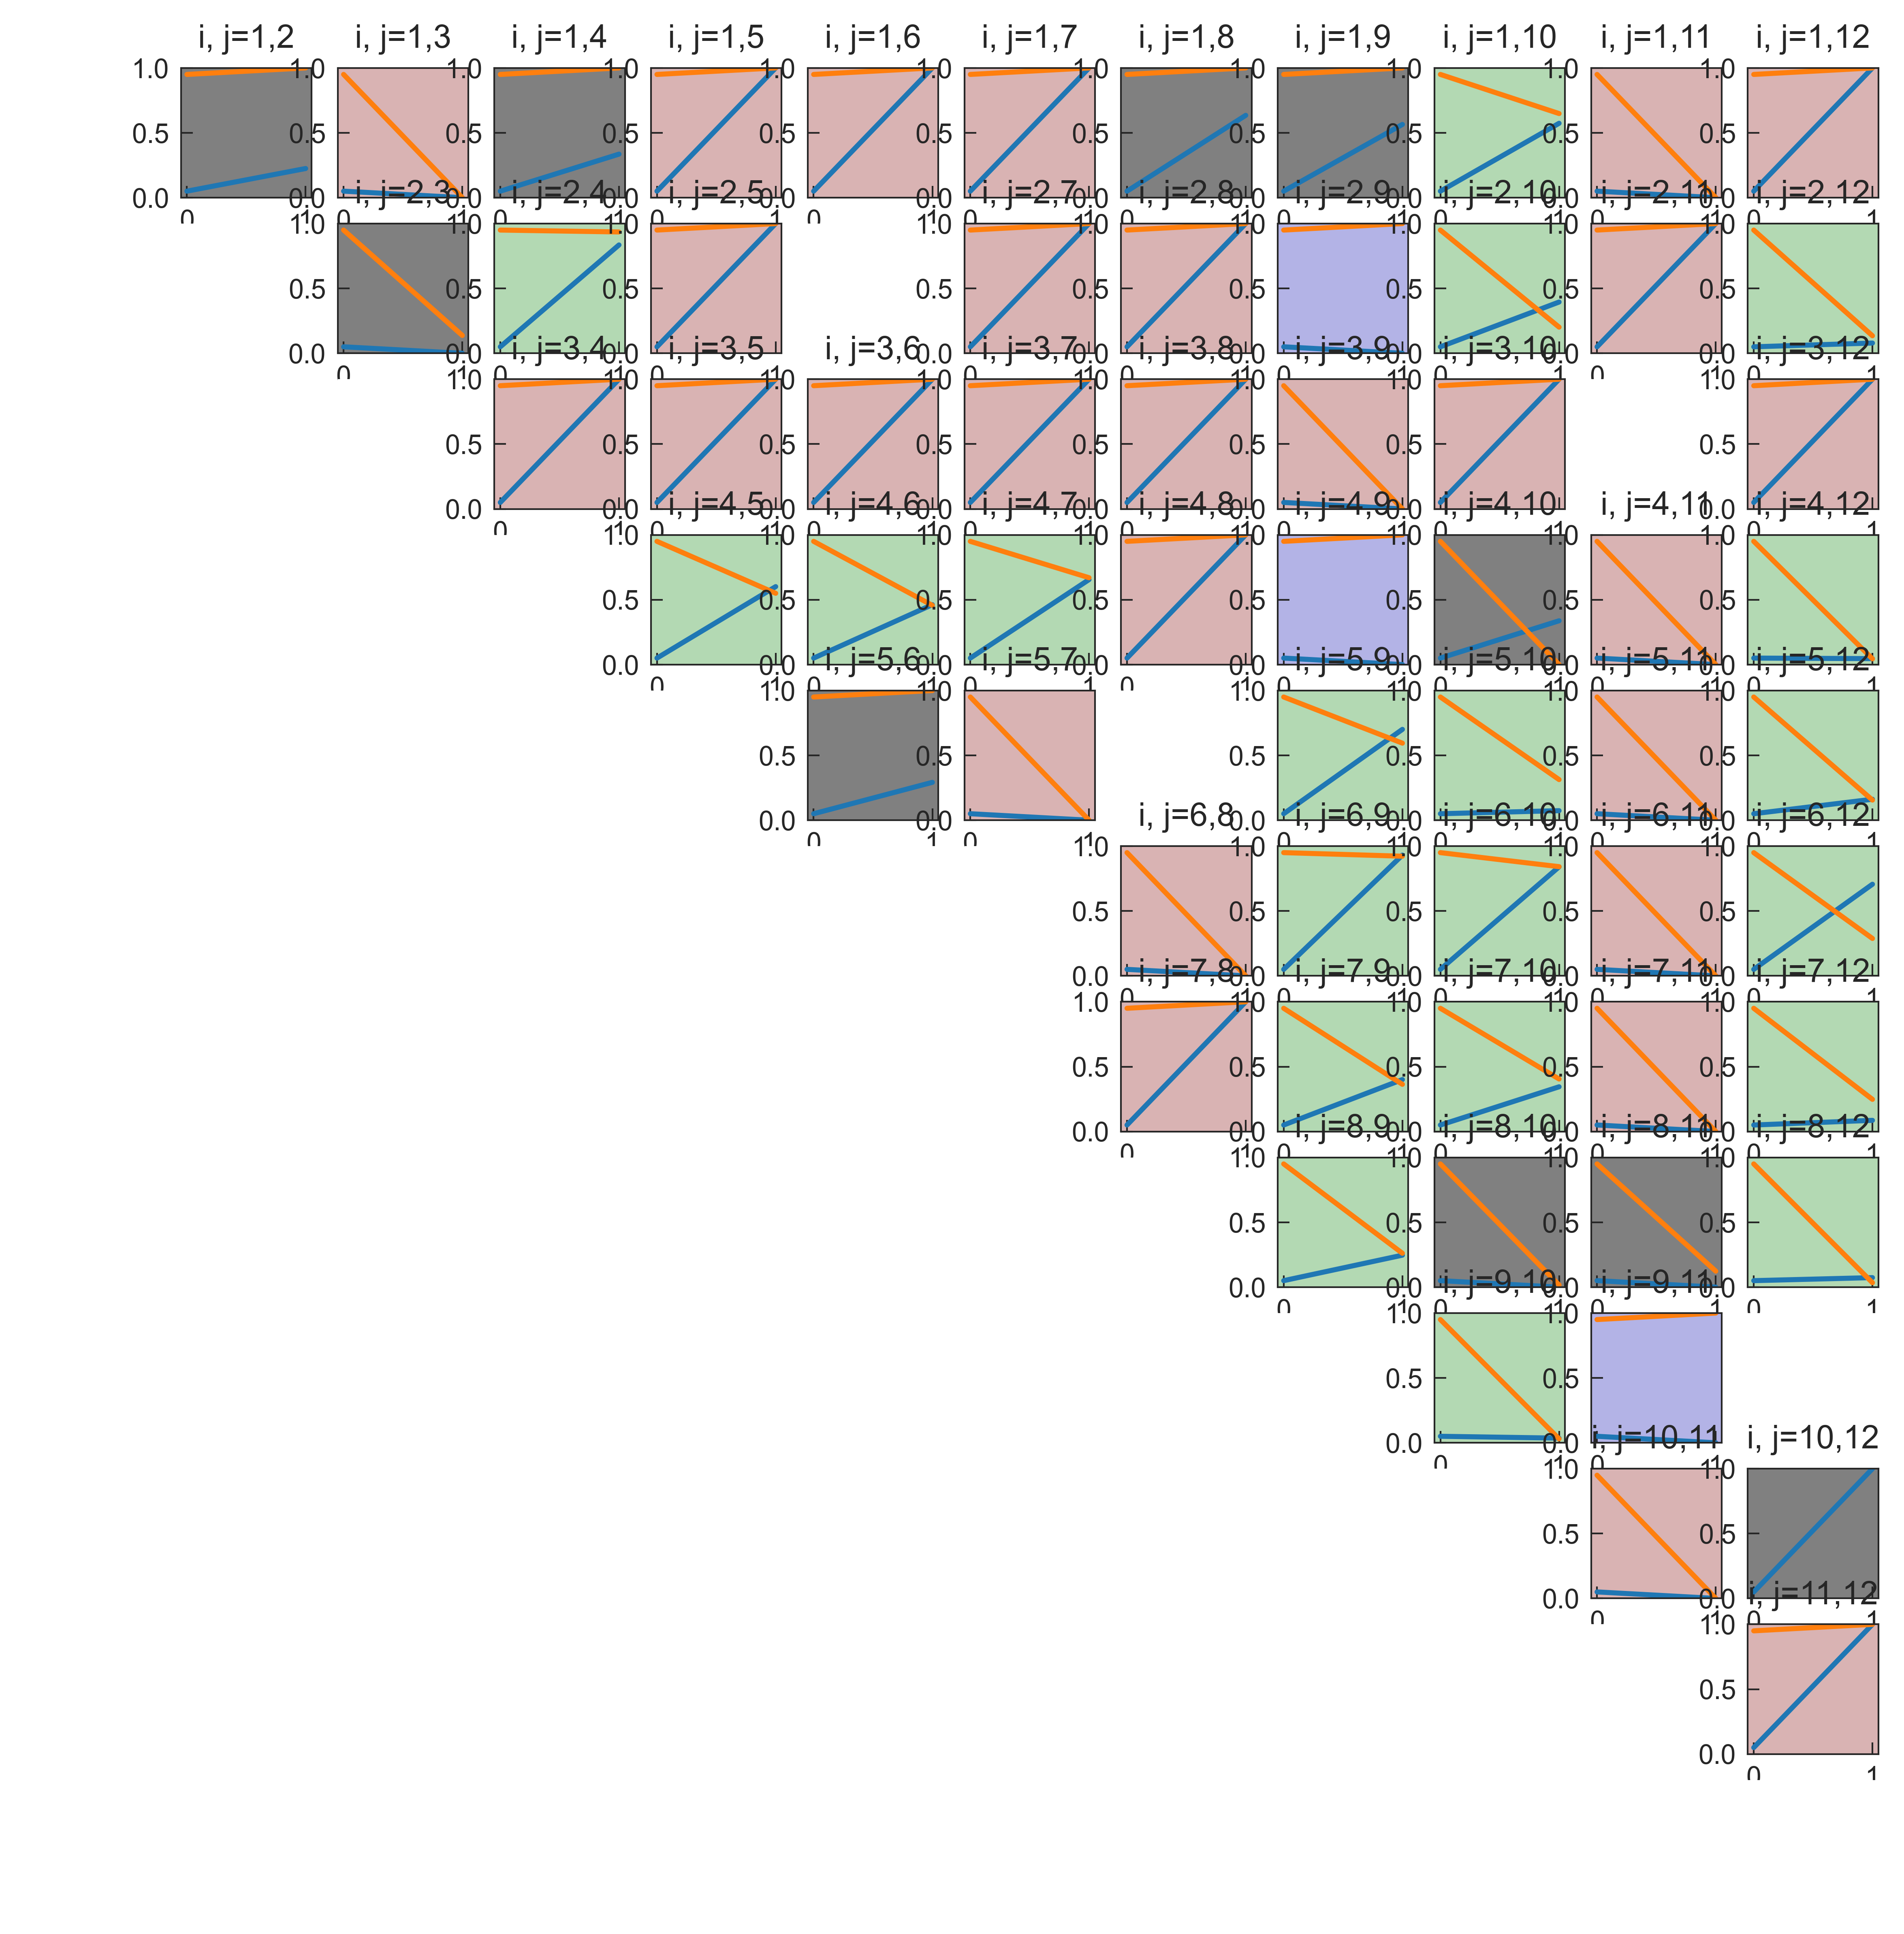

In [ ]:
data_p_1,data_p_2,data_flag,data_p_ratio=getProcessedPairwiseCountData(Mono_Count_data, Pairwise_Count_data, 'MN')

def drawPairwiseChange(i, j, x):
    # This is just a sample function. Replace this with your function.
    return np.sin(i*x) + np.cos(j*x)

def InterpretPairwiseResult(y1,y2):
    if y1==1 and y2==1:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==0:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==1:
        return 'B',(0.7, 0.7, 0.9) #B : Bistability
    elif y1>0 and y1<1 and y2>0 and y2<1:
        return 'C',(0.7, 0.85, 0.7) #C : Coexistence
    else:
        return 'U',(0.5, 0.5, 0.5) #U : Unclassified

N=12
fig, axs = plt.subplots(N, N, figsize=(250*mm,250*mm))

case_list=[]
for i in range(12):
    for j in range(12):
        if j<=i:
            axs[i,j].spines['top'].set_visible(False)
            axs[i,j].spines['right'].set_visible(False)
            axs[i,j].spines['bottom'].set_visible(False)
            axs[i,j].spines['left'].set_visible(False)
            axs[i,j].get_xaxis().set_ticks([])
            axs[i,j].get_yaxis().set_ticks([])
        elif data_flag[i,j]=='case0':
            axs[i,j].spines['top'].set_visible(False)
            axs[i,j].spines['right'].set_visible(False)
            axs[i,j].spines['bottom'].set_visible(False)
            axs[i,j].spines['left'].set_visible(False)
            axs[i,j].get_xaxis().set_ticks([])
            axs[i,j].get_yaxis().set_ticks([])
        else:    
            x1=[0,1]
            y1=[0.05,data_p_ratio[i,j]]
            axs[i, j].plot(x1, y1)
            x2=[0,1]
            y2=[0.95,1-data_p_ratio[j,i]]
            axs[i, j].plot(x2, y2)
            
            axs[i, j].set_ylim(0,1)
            
            case,shade = InterpretPairwiseResult(y1[1],y2[1])
            case_list.append(case)
            axs[i, j].set_facecolor(shade)
            #axs[i, j].patch.set_alpha(0.5)
            
            axs[i, j].set_title(f'i, j={i+1},{j+1}')
        # Other subplot-specific formatting goes here

Hierarchy Score: 0.758
Null Expectation: 0.425 ± 0.084


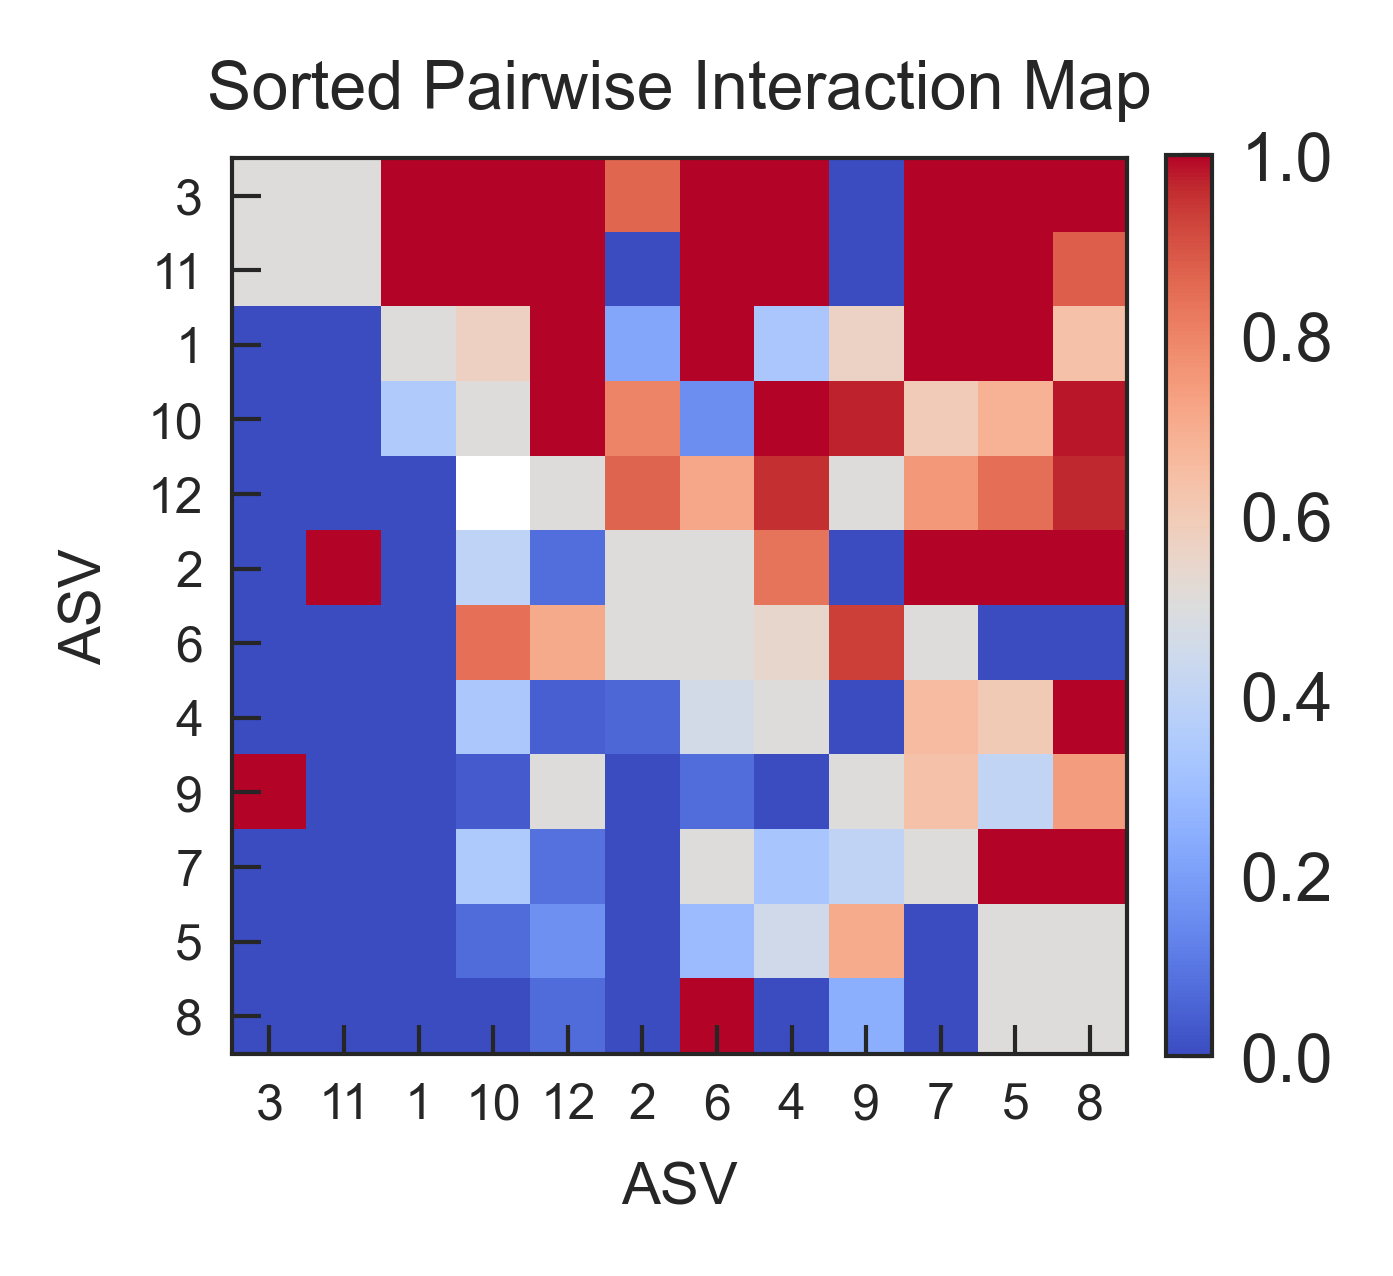

In [23]:
import numpy as np
import matplotlib.pyplot as plt
data_p_ratio = np.where(data_p_ratio == None, 0.5, data_p_ratio).astype(np.float64)
def compute_hierarchy_score(data_p_ratio):
    N = data_p_ratio.shape[0]
    score_matrix = np.zeros((N, N))
    
    # Step 1: get strength ranking
    strength = np.nansum(data_p_ratio > 0.5, axis=1)
    ranking = np.argsort(-strength)  # strongest first
    
    # Step 2: compute hierarchy score
    num_pairs = 0
    num_agree = 0
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            # if i ranks higher than j, check direction of win
            rank_i = np.where(ranking == i)[0][0]
            rank_j = np.where(ranking == j)[0][0]
            if rank_i < rank_j:  # i should beat j
                if not np.isnan(data_p_ratio[i,j]):
                    num_pairs += 1
                    if data_p_ratio[i,j] > 0.5:
                        num_agree += 1
    hierarchy_score = num_agree / num_pairs
    return hierarchy_score, ranking

def compute_null_hierarchy(data_p_ratio, num_samples=1000):
    N = data_p_ratio.shape[0]
    scores = []
    for _ in range(num_samples):
        perm = np.random.permutation(N)
        num_pairs = 0
        num_agree = 0
        for i in range(N):
            for j in range(N):
                if i == j:
                    continue
                rank_i = np.where(perm == i)[0][0]
                rank_j = np.where(perm == j)[0][0]
                if rank_i < rank_j:
                    if not np.isnan(data_p_ratio[i,j]):
                        num_pairs += 1
                        if data_p_ratio[i,j] > 0.5:
                            num_agree += 1
        scores.append(num_agree / num_pairs)
    return np.mean(scores), np.std(scores), scores

def plot_sorted_interaction_map(data_p_ratio, ranking, 
                                title="Sorted Pairwise Interaction Map",
                                save_path="/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230404/Figure_generate/code/Figure/pairwise_heatmap_MN.svg"):
    mm_to_inch = 1 / 25.4
    fig, ax = plt.subplots(figsize=(60 * mm_to_inch, 60 * mm_to_inch))
    
    sorted_matrix = data_p_ratio[ranking, :][:, ranking]
    cax = ax.imshow(sorted_matrix, cmap='coolwarm', vmin=0, vmax=1)
    
    ax.set_xticks(np.arange(len(ranking)))
    ax.set_yticks(np.arange(len(ranking)))
    ax.set_xticklabels(ranking + 1, fontsize=6)
    ax.set_yticklabels(ranking + 1, fontsize=6)
    ax.set_xlabel("ASV", fontsize=7)
    ax.set_ylabel("ASV", fontsize=7)
    ax.set_title(title, fontsize=8)
    
    plt.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()

    
    return fig

# Clean and compute
data_p_ratio = np.array(data_p_ratio, dtype=np.float64)
hierarchy_score, ranking = compute_hierarchy_score(data_p_ratio)
null_mean, null_std, null_scores = compute_null_hierarchy(data_p_ratio)

# Print hierarchy score
print(f"Hierarchy Score: {hierarchy_score:.3f}")
print(f"Null Expectation: {null_mean:.3f} ± {null_std:.3f}")

# Generate and save figure
fig = plot_sorted_interaction_map(data_p_ratio, ranking)
fig.savefig("/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230404/Figure_generate/code/Figure/pairwise_heatmap_MN.svg", format="svg")


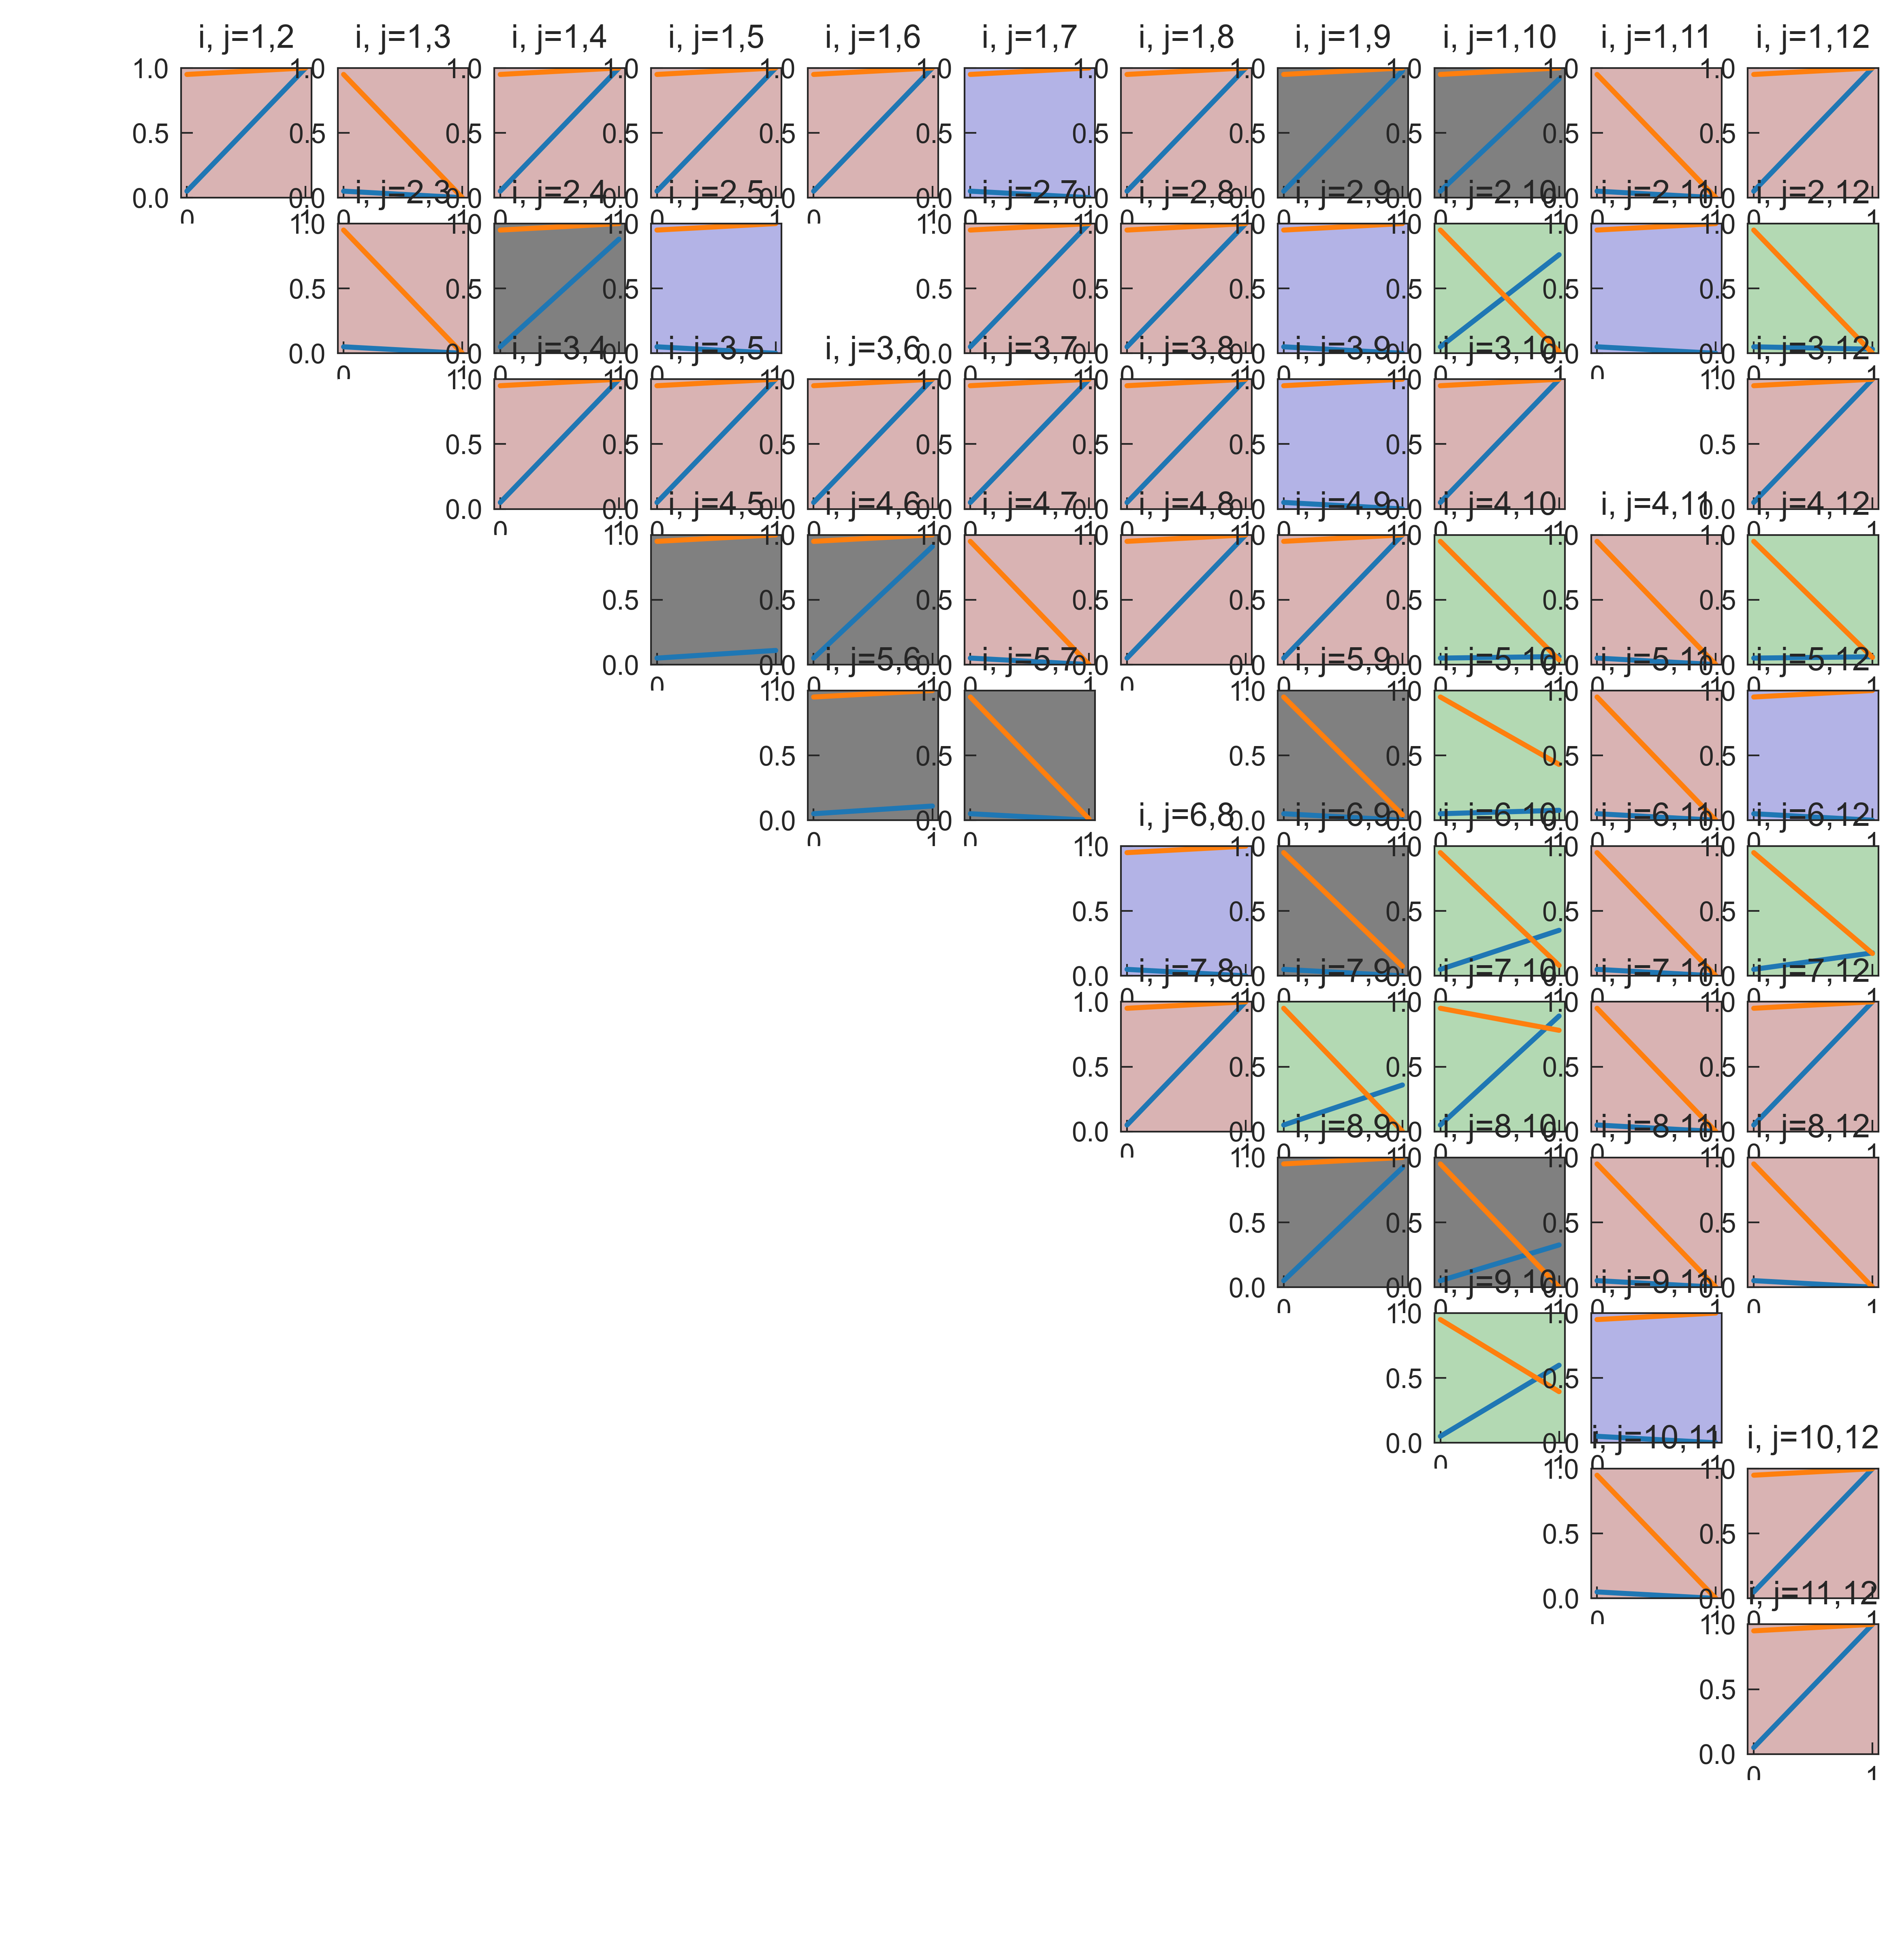

In [25]:
data_p_1,data_p_2,data_flag,data_p_ratio=getProcessedPairwiseCountData(Mono_Count_data, Pairwise_Count_data, 'HN')

def drawPairwiseChange(i, j, x):
    # This is just a sample function. Replace this with your function.
    return np.sin(i*x) + np.cos(j*x)

def InterpretPairwiseResult(y1,y2):
    if y1==1 and y2==1:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==0:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==1:
        return 'B',(0.7, 0.7, 0.9) #B : Bistability
    elif y1>0 and y1<1 and y2>0 and y2<1:
        return 'C',(0.7, 0.85, 0.7) #C : Coexistence
    else:
        return 'U',(0.5, 0.5, 0.5) #U : Unclassified

N=12
fig, axs = plt.subplots(N, N, figsize=(250*mm,250*mm))

case_list=[]
for i in range(12):
    for j in range(12):
        if j<=i:
            axs[i,j].spines['top'].set_visible(False)
            axs[i,j].spines['right'].set_visible(False)
            axs[i,j].spines['bottom'].set_visible(False)
            axs[i,j].spines['left'].set_visible(False)
            axs[i,j].get_xaxis().set_ticks([])
            axs[i,j].get_yaxis().set_ticks([])
        elif data_flag[i,j]=='case0':
            axs[i,j].spines['top'].set_visible(False)
            axs[i,j].spines['right'].set_visible(False)
            axs[i,j].spines['bottom'].set_visible(False)
            axs[i,j].spines['left'].set_visible(False)
            axs[i,j].get_xaxis().set_ticks([])
            axs[i,j].get_yaxis().set_ticks([])
        else:    
            x1=[0,1]
            y1=[0.05,data_p_ratio[i,j]]
            axs[i, j].plot(x1, y1)
            x2=[0,1]
            y2=[0.95,1-data_p_ratio[j,i]]
            axs[i, j].plot(x2, y2)
            
            axs[i, j].set_ylim(0,1)
            
            case,shade = InterpretPairwiseResult(y1[1],y2[1])
            case_list.append(case)
            axs[i, j].set_facecolor(shade)
            #axs[i, j].patch.set_alpha(0.5)
            
            axs[i, j].set_title(f'i, j={i+1},{j+1}')
        # Other subplot-specific formatting goes here

Hierarchy Score: 0.667
Null Expectation: 0.400 ± 0.082


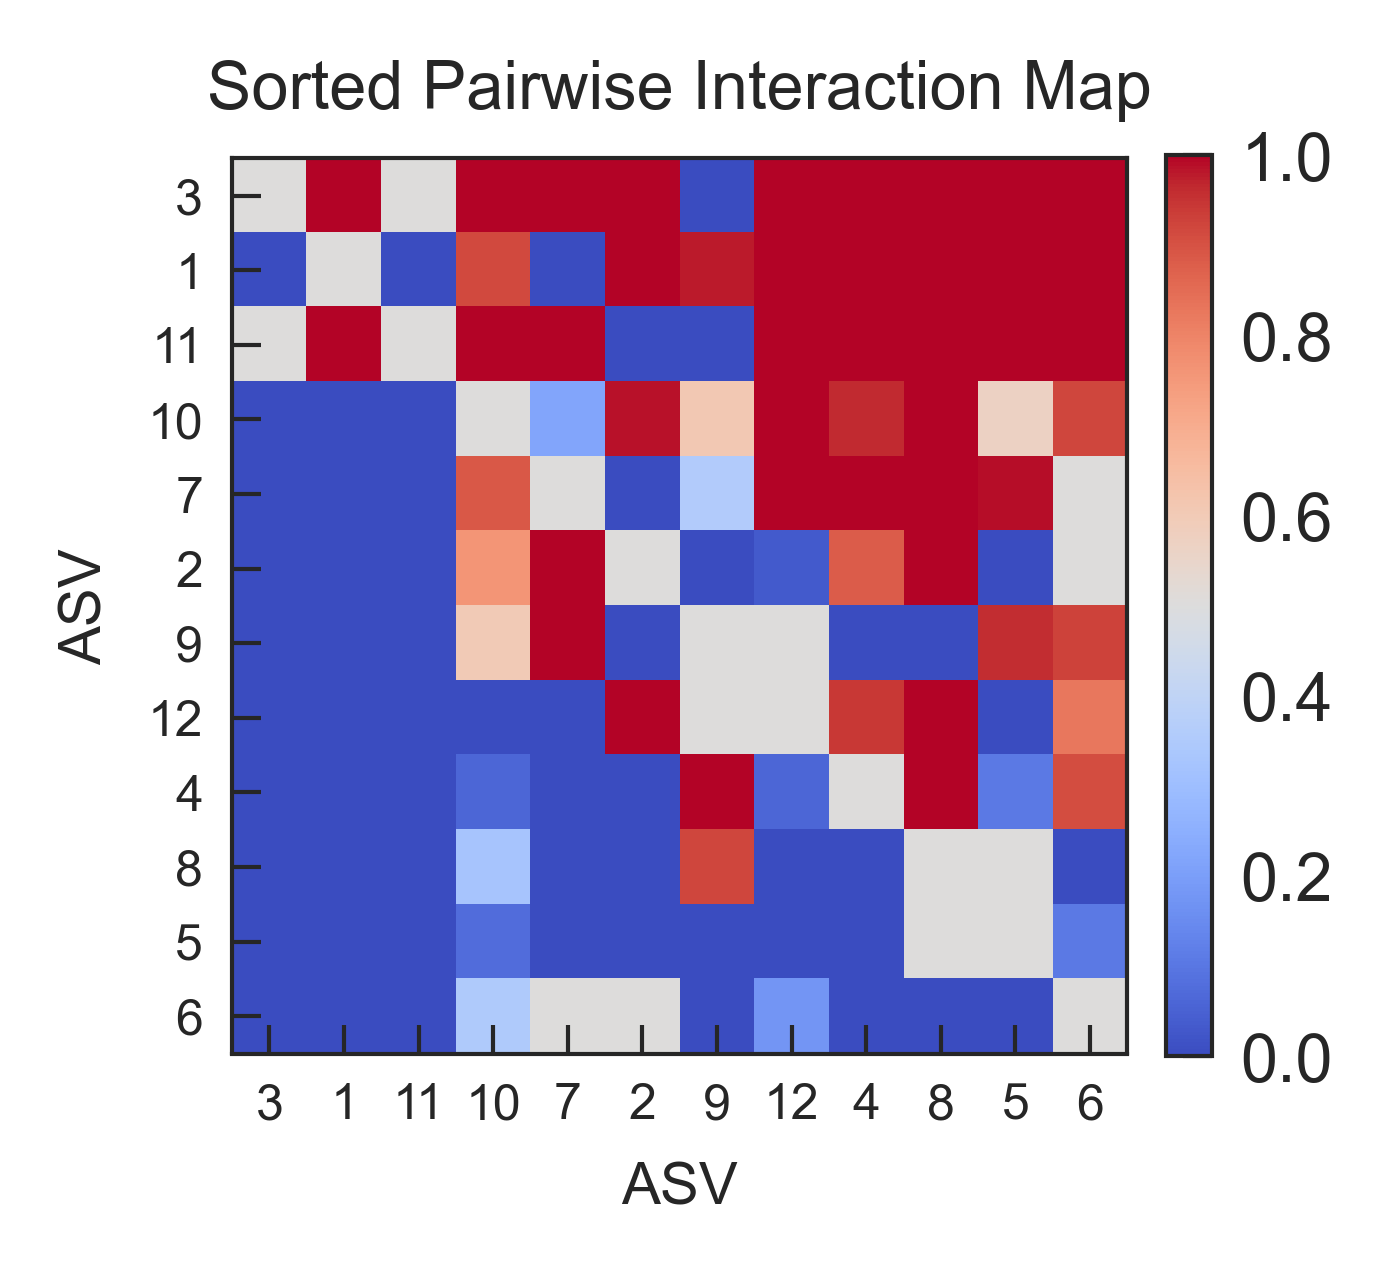

In [26]:
import numpy as np
import matplotlib.pyplot as plt
data_p_ratio = np.where(data_p_ratio == None, 0.5, data_p_ratio).astype(np.float64)
def compute_hierarchy_score(data_p_ratio):
    N = data_p_ratio.shape[0]
    score_matrix = np.zeros((N, N))
    
    # Step 1: get strength ranking
    strength = np.nansum(data_p_ratio > 0.5, axis=1)
    ranking = np.argsort(-strength)  # strongest first
    
    # Step 2: compute hierarchy score
    num_pairs = 0
    num_agree = 0
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            # if i ranks higher than j, check direction of win
            rank_i = np.where(ranking == i)[0][0]
            rank_j = np.where(ranking == j)[0][0]
            if rank_i < rank_j:  # i should beat j
                if not np.isnan(data_p_ratio[i,j]):
                    num_pairs += 1
                    if data_p_ratio[i,j] > 0.5:
                        num_agree += 1
    hierarchy_score = num_agree / num_pairs
    return hierarchy_score, ranking

def compute_null_hierarchy(data_p_ratio, num_samples=1000):
    N = data_p_ratio.shape[0]
    scores = []
    for _ in range(num_samples):
        perm = np.random.permutation(N)
        num_pairs = 0
        num_agree = 0
        for i in range(N):
            for j in range(N):
                if i == j:
                    continue
                rank_i = np.where(perm == i)[0][0]
                rank_j = np.where(perm == j)[0][0]
                if rank_i < rank_j:
                    if not np.isnan(data_p_ratio[i,j]):
                        num_pairs += 1
                        if data_p_ratio[i,j] > 0.5:
                            num_agree += 1
        scores.append(num_agree / num_pairs)
    return np.mean(scores), np.std(scores), scores

def plot_sorted_interaction_map(data_p_ratio, ranking, 
                                title="Sorted Pairwise Interaction Map",
                                save_path="/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230404/Figure_generate/code/Figure/pairwise_heatmap_MN.svg"):
    mm_to_inch = 1 / 25.4
    fig, ax = plt.subplots(figsize=(60 * mm_to_inch, 60 * mm_to_inch))
    
    sorted_matrix = data_p_ratio[ranking, :][:, ranking]
    cax = ax.imshow(sorted_matrix, cmap='coolwarm', vmin=0, vmax=1)
    
    ax.set_xticks(np.arange(len(ranking)))
    ax.set_yticks(np.arange(len(ranking)))
    ax.set_xticklabels(ranking + 1, fontsize=6)
    ax.set_yticklabels(ranking + 1, fontsize=6)
    ax.set_xlabel("ASV", fontsize=7)
    ax.set_ylabel("ASV", fontsize=7)
    ax.set_title(title, fontsize=8)
    
    plt.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()

    
    return fig

# Clean and compute
data_p_ratio = np.array(data_p_ratio, dtype=np.float64)
hierarchy_score, ranking = compute_hierarchy_score(data_p_ratio)
null_mean, null_std, null_scores = compute_null_hierarchy(data_p_ratio)

# Print hierarchy score
print(f"Hierarchy Score: {hierarchy_score:.3f}")
print(f"Null Expectation: {null_mean:.3f} ± {null_std:.3f}")

# Generate and save figure
fig = plot_sorted_interaction_map(data_p_ratio, ranking)
fig.savefig("/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230404/Figure_generate/code/Figure/pairwise_heatmap_HN.svg", format="svg")


In [24]:
## Second choice : Include every species number together

# Set community Variable
Variable2plot='SimilarityTo1_J_5'
medium="H"
species_num=0
com_type="S"
rep=-1

data_p_1,data_p_2,data_flag,data_p_ratio=getProcessedPairwiseCountData(Mono_Count_data, Pairwise_Count_data, medium+'N')

# Set Hyper parameter Variable
alphas=np.logspace(-5, -1, num=2)
betas=np.logspace(-2, 2, num=10)
order=1
preprocess='Tan' ##'Basic', 'Normalize', 'ArcTanh'

IDX_list=np.array([])
x=np.array([[]])
y=np.array([])

for species_num in [12]:

    Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
    Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)
    
    matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
    df = pd.DataFrame(matrix)
    df_sorted=df.sort_index(axis=1)
    df_sorted=df_sorted.sort_index(axis=0)
    competitive_scores = [np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

    # Sort rows and columns by competitive score
    sorted_idx = np.argsort(competitive_scores)[::-1]
    df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
    competitive_scores_sorted = [np.mean(df_sorted.loc[row_col,:]) for row_col in df_sorted.index]
    x_list= getAbundance_fromList(Processed_sequences_synthetic,df_sorted.keys())

    x=[]
    y=[]
    mostAb=[]
    count_noncase=0
    count_total=0
    for i in range(len(df_sorted.keys())):
        for j in range(len(df_sorted.keys())):
            Coal_val=df_sorted.values[i,j]
            
            if ~isnan(Coal_val) and Coal_val!=0.5:
                C1=x_list[i,:]
                C1=argmax(C1)
                C2=x_list[j,:]
                C2=argmax(C2)
                if data_p_ratio[C1,C2]==None:
                    count_total=count_total+1
                    count_noncase=count_noncase+1
                else:
                    count_total=count_total+1
                    y.append(Coal_val)
                    mostAb.append((C1,C2))
                    x.append(np.mean([1-data_p_ratio[C1,C2],data_p_ratio[C2,C1]]))
x=np.array(x)
y=np.array(y)
print(count_noncase,count_total)

colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

if True:
    i=1
    plt.scatter(x,y,s=0.5)
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
        # Create a scatter plot of the data
    plt.scatter(x, y, color=colors[i], s=4)
    # Add the linear regression line to the plot
    plt.plot([0,1], slope * np.array([0,1]) + intercept, color=colors[i], alpha=0.8)
                # Add the R-squared value to the plot
    plt.annotate('$R^2$ = {:.2f}'.format(r_squared), xy=(0.05+0.6, 0.65), xycoords='axes fraction', fontsize=12, color=colors[i])

    plt.xlabel('Average Competitive Score')
    plt.ylabel('Final pH')
    plt.xlim(-0.05,1.05)

NameError: name 'getDominanceMatrix' is not defined

In [259]:
np.mean(abs(y-0.5))

0.37441732530384964